# Practice with matrices

The two examples here are common things that can go wrong when you create a matrix "incorrectly". Not that the matrix is actually incorrect (math or syntax), just that it isn't what you (usually) want for moving objects around.

See also Lecture slides https://docs.google.com/presentation/d/12p3VOVT5yL14-1z5T20hTscpVC0hsxjtvMLHmQLFITk/edit?usp=sharing

In [1]:
import numpy as np
from matplotlib import pyplot as plt

# All of the matrix routines are in here - we can import the Python (.py) file just like the imports above
#  All of the functions in there will be accessed as mr.
import matrix_routines as mr

# The same plot functions as were used in the tutorial
from matrix_routines import plot_pts, plot_axes_and_big_box, plot_transformed_axes

In [2]:
## The points from the tutorial - plus some other ones you can practice with
# It's easier to start with a numpy array that has ones in it to make the points because you'll need ones in the 3rd row
n_points = 3
pts_triangle = np.ones((3, n_points))
# Make a right-sided triangle with the center of the origin in the middle
pts_triangle[0:2, 0] = [-2.0, 1.25]  # Upper left corner
pts_triangle[0:2, 1] = [2.0, -0.5]   # Pointy bit at the right
pts_triangle[0:2, 2] = [-2.0, -0.5]   # 90 degree angle part

# Points on a circle
n_pts_circle = 32
# The angles
thetas = np.linspace(0, np.pi * 2, n_pts_circle)
pts_circle = np.ones(shape=(3, n_pts_circle))
pts_circle[0, :] = np.cos(thetas)
pts_circle[1, :] = np.sin(thetas)

### Example: Uncentered geometry

A common (and subtle) problem is that (most of the time) the assumption is that the geometry is centered around the origin - otherwise, when you rotate the object it moves, too.

For the first example, the matrix transform stays the same but the object is in a different place

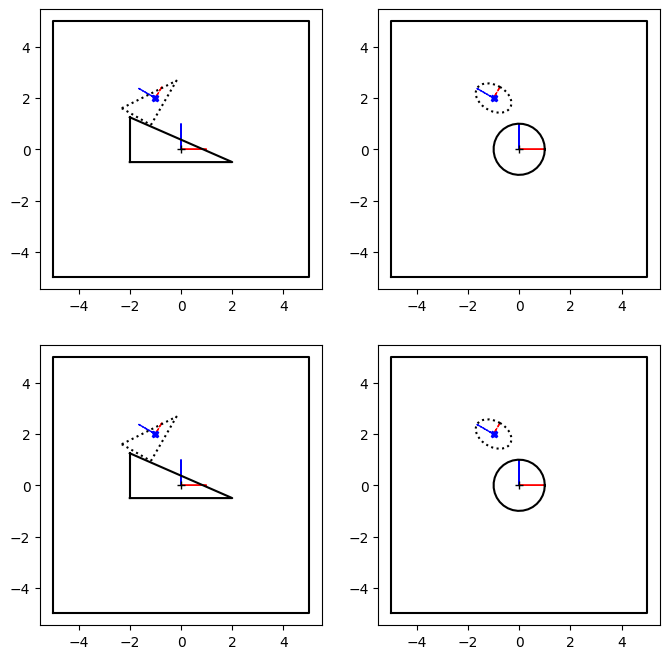

In [3]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8))

# First plot is the "normal" one

# GUIDE: Change the two mat_trans to move the lower left point of the shape to the origin
mat_trans_triangle = mr.make_translation_matrix(0, 0)
mat_trans_circle = mr.make_translation_matrix(1, 1)  # Move -1, -1 to 0,0
pts_triangle_lower_left_origin = pts_triangle   # Put the matrix before pts_triangle
pts_circle_lower_left_origin = pts_circle  # Put a matrix before pts_circle


# Make a scale, rotation, translation matrix
mat_scl_rot_trans = mr.make_translation_matrix(-1, 2) @ \
                    mr.make_rotation_matrix(np.pi / 3.0) @ \
                    mr.make_scale_matrix(0.5, 0.75)   # pts go here


# Plot the big box and axes for all plots
for i in range(0, 4):
    plot_axes_and_big_box(axs[i // 2, i % 2])


first_row = (pts_triangle, pts_circle)
second_row = (pts_triangle_lower_left_origin, pts_circle_lower_left_origin)
for ir, row in enumerate((first_row, second_row)):
    for ic, pts in enumerate(row):
        # Draw the original points
        plot_pts(axs[ir, ic], pts)

        # This is the transformation for all four cases
        plot_transformed_axes(axs[ir, ic], mat_scl_rot_trans)

        # Plot the transformed points
        pts_transformed = mat_scl_rot_trans @ pts
        plot_pts(axs[ir, ic], pts_transformed, fmt=":k")


# Answers

Note: Just putting the lines that need to change here


In [4]:
mat_trans_triangle = mr.make_translation_matrix(-pts_triangle[0, -1], -pts_triangle[1, -1]) # Move the lower left corner (the last point) to (0,0)
mat_trans_circle = mr.make_translation_matrix(0, 0)

pts_triangle_lower_left_origin = mat_trans_triangle @ pts_triangle   # Put the matrix before pts_triangle
pts_circle_lower_left_origin = mat_trans_circle @ pts_circle  # Put a matrix before pts_circle
